# PCA 차원 축소 및 특성 융합
- 추출된 768차원의 KcBERT 임베딩은 다른 메타데이터(4차원)에 비해 차원이 지나치게 커서 모델 학습 시 불균형을 초래할 수 있다.
- 주성분 분석(PCA)을 통해 텍스트 임베딩의 차원을 축소한다.
- 축소된 텍스트 피처와 정규화된 메타데이터를 결합(Fusion)하여 최종 학습용 데이터셋(X, y)을 구축한다.

### 라이브러리 로드
- 차원 축소 및 데이터 스케일링을 위한 scikit-learn 패키지를 임포트한다.
  1. sklearn.decomposition.PCA: 주성분 분석(차원 축소)
  2. sklearn.preprocessing.StandardScaler: 데이터 표준화(정규화)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### 데이터 로드
- 이전 단계에서 저장한 `reviews_with_embeddings.csv` 파일을 불러온다.
- 768개의 KcBERT 임베딩 컬럼(`kcbert_0` ~ `kcbert_767`)만 별도로 추출하여 행렬 형태로 준비한다.

In [2]:
df = pd.read_csv('csv/reviews_embeddings_extract.csv')

# KcBERT 임베딩 컬럼
emb_cols = [f'kcbert_{i}' for i in range(768)]

# 메타데이터 컬럼
meta_cols = ['rating', 'text_length', 'emoji_count', 'photo_count']

# 입력 데이터 분리
X_emb = df[emb_cols].values
X_meta = df[meta_cols].values
y = df['label'].values

# 1차 분할: train 70%, temp 30%
X_emb_train, X_emb_temp, X_meta_train, X_meta_temp, y_train, y_temp = train_test_split(
    X_emb,
    X_meta,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: validation 15%, test 15%
X_emb_val, X_emb_test, X_meta_val, X_meta_test, y_val, y_test = train_test_split(
    X_emb_temp,
    X_meta_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"전체 임베딩 형태: {X_emb.shape}")
print(f"학습 임베딩 형태: {X_emb_train.shape}")
print(f"검증 임베딩 형태: {X_emb_val.shape}")
print(f"테스트 임베딩 형태: {X_emb_test.shape}")

전체 임베딩 형태: (8840, 768)
학습 임베딩 형태: (6188, 768)
검증 임베딩 형태: (1326, 768)
테스트 임베딩 형태: (1326, 768)


/var/folders/wq/j2lqqp7n33dgrwj1r4q0nl9m0000gn/T/ipykernel_75392/73623162.py:1: DtypeWarning: Columns (0: store_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('csv/reviews_embeddings_extract.csv')


### PCA 차원 축소 및 시각화
- 원본 데이터의 정보량(분산)을 90% 보존하는 수준(`n_components=0.90`)으로 차원을 축소한다.
- 축소 전후의 누적 설명 분산 비율(Cumulative Explained Variance)을 시각화하여, 적절한 차원으로 압축되었는지 확인한다.

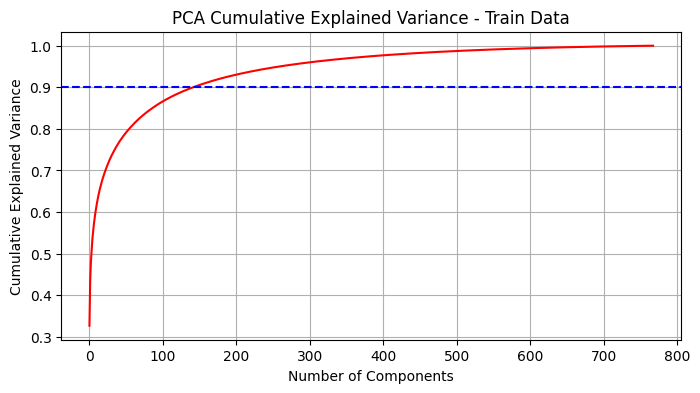

차원 축소 전 학습 데이터 형태: (6188, 768)
차원 축소 후 학습 데이터 형태: (6188, 142)
차원 축소 후 검증 데이터 형태: (1326, 142)
차원 축소 후 테스트 데이터 형태: (1326, 142)
PCA 선택 차원 수: 142


In [3]:
# 학습 데이터 기준으로만 PCA fit
pca = PCA(n_components=0.90, random_state=42)

X_emb_train_pca = pca.fit_transform(X_emb_train)
X_emb_val_pca = pca.transform(X_emb_val)
X_emb_test_pca = pca.transform(X_emb_test)

# 시각화도 학습 데이터 기준으로만 확인
pca_full = PCA().fit(X_emb_train)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red')
plt.axhline(y=0.9, color='blue', linestyle='--')
plt.title('PCA Cumulative Explained Variance - Train Data')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

print(f"차원 축소 전 학습 데이터 형태: {X_emb_train.shape}")
print(f"차원 축소 후 학습 데이터 형태: {X_emb_train_pca.shape}")
print(f"차원 축소 후 검증 데이터 형태: {X_emb_val_pca.shape}")
print(f"차원 축소 후 테스트 데이터 형태: {X_emb_test_pca.shape}")
print(f"PCA 선택 차원 수: {pca.n_components_}")

### 메타데이터 정규화 (StandardScaler)
- 메타데이터(별점, 텍스트 길이, 이모지 개수, 사진 개수)의 단위와 스케일이 서로 다르므로 표준화(평균 0, 표준편차 1)를 진행한다.
- 정규화를 통해 모델이 특정 메타데이터 컬럼에 과적합되거나 편향되는 것을 방지한다.

In [4]:
# 학습 데이터 기준으로만 StandardScaler fit
scaler = StandardScaler()

X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_val_scaled = scaler.transform(X_meta_val)
X_meta_test_scaled = scaler.transform(X_meta_test)

print(f"스케일링 전 학습 메타데이터 예시:\n{X_meta_train[0]}")
print(f"스케일링 후 학습 메타데이터 예시:\n{X_meta_train_scaled[0]}")
print(f"학습 메타데이터 형태: {X_meta_train_scaled.shape}")
print(f"검증 메타데이터 형태: {X_meta_val_scaled.shape}")
print(f"테스트 메타데이터 형태: {X_meta_test_scaled.shape}")

스케일링 전 학습 메타데이터 예시:
[  5. 221.   0.   1.]
스케일링 후 학습 메타데이터 예시:
[ 0.22491584  2.73109027 -0.35469453  0.12050323]
학습 메타데이터 형태: (6188, 4)
검증 메타데이터 형태: (1326, 4)
테스트 메타데이터 형태: (1326, 4)


### 특성 융합 (Feature Fusion) 및 정답지 추가
- 축소된 PCA 임베딩(텍스트 문맥 정보)과 정규화된 메타데이터(사용자 행동 정보)를 수평 결합(`np.hstack`)한다.
- 결합된 피처들을 `feat_0`, `feat_1` 등의 컬럼명으로 명명하고, 메타데이터 컬럼명은 직관적으로 변경한다.
- 모델이 예측해야 할 최종 정답지인 `label` 컬럼을 `target_label`로 추가한다.

In [5]:
# PCA 임베딩과 정규화된 메타데이터 결합
X_train_final = np.hstack([X_emb_train_pca, X_meta_train_scaled])
X_val_final = np.hstack([X_emb_val_pca, X_meta_val_scaled])
X_test_final = np.hstack([X_emb_test_pca, X_meta_test_scaled])

# PCA 차원 수 확인
pca_dim = X_emb_train_pca.shape[1]

# 컬럼명 생성
column_names = [f'feat_{i}' for i in range(X_train_final.shape[1])]

df_train_final = pd.DataFrame(X_train_final, columns=column_names)
df_val_final = pd.DataFrame(X_val_final, columns=column_names)
df_test_final = pd.DataFrame(X_test_final, columns=column_names)

# 정답 label 추가
df_train_final['target_label'] = y_train
df_val_final['target_label'] = y_val
df_test_final['target_label'] = y_test

# 마지막 4개 컬럼명을 메타데이터 이름으로 변경
rename_dict = {
    f'feat_{pca_dim}': 'meta_rating',
    f'feat_{pca_dim + 1}': 'meta_text_length',
    f'feat_{pca_dim + 2}': 'meta_emoji_count',
    f'feat_{pca_dim + 3}': 'meta_photo_count'
}

df_train_final = df_train_final.rename(columns=rename_dict)
df_val_final = df_val_final.rename(columns=rename_dict)
df_test_final = df_test_final.rename(columns=rename_dict)

print(f"PCA 차원 수: {pca_dim}")
print(f"최종 학습 데이터프레임 형태: {df_train_final.shape}")
print(f"최종 검증 데이터프레임 형태: {df_val_final.shape}")
print(f"최종 테스트 데이터프레임 형태: {df_test_final.shape}")

df_train_final.head()

PCA 차원 수: 142
최종 학습 데이터프레임 형태: (6188, 147)
최종 검증 데이터프레임 형태: (1326, 147)
최종 테스트 데이터프레임 형태: (1326, 147)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_137,feat_138,feat_139,feat_140,feat_141,meta_rating,meta_text_length,meta_emoji_count,meta_photo_count,target_label
0,17.115861,-2.558821,4.752327,5.155748,2.804719,2.411738,1.303864,-1.131253,-0.674005,0.763395,...,0.232088,-0.300686,0.220494,0.202372,-0.140032,0.224916,2.731090,-0.354695,0.120503,1
1,-13.308886,0.848647,6.937217,1.641180,-4.114059,0.186172,-0.811025,-1.513030,0.421992,-0.254603,...,0.227148,0.549360,0.548809,-0.336195,-0.098243,0.224916,-0.791357,-0.354695,0.120503,1
2,-4.490754,1.873577,-3.560444,0.191874,-3.274708,1.973618,0.701743,-3.484273,0.930147,1.426205,...,0.168998,-0.123347,-0.314633,-0.258086,0.885565,0.224916,-0.608588,0.798972,-1.180848,0
3,-7.597287,4.038915,-2.497244,2.967637,-4.023279,0.919815,-0.961265,-2.601625,-2.558129,2.881189,...,-0.115129,0.276496,-0.140387,-0.419960,0.013443,0.224916,-0.625204,-0.354695,-1.180848,1
4,13.189534,-3.647755,3.802826,3.586880,1.048759,-2.579177,3.076115,1.377090,0.804230,-1.595023,...,0.201174,-0.483461,0.002359,-0.293541,-0.146049,-1.710799,-0.060283,-0.354695,0.120503,1


### 최종 데이터 산출

In [6]:
train_output_csv = 'csv/final_hybrid_train.csv'
val_output_csv = 'csv/final_hybrid_val.csv'
test_output_csv = 'csv/final_hybrid_test.csv'

df_train_final.to_csv(train_output_csv, index=False, encoding='utf-8-sig')
df_val_final.to_csv(val_output_csv, index=False, encoding='utf-8-sig')
df_test_final.to_csv(test_output_csv, index=False, encoding='utf-8-sig')

print(f"학습 데이터가 {train_output_csv}로 저장되었습니다.")
print(f"검증 데이터가 {val_output_csv}로 저장되었습니다.")
print(f"테스트 데이터가 {test_output_csv}로 저장되었습니다.")

학습 데이터가 csv/final_hybrid_train.csv로 저장되었습니다.
검증 데이터가 csv/final_hybrid_val.csv로 저장되었습니다.
테스트 데이터가 csv/final_hybrid_test.csv로 저장되었습니다.
